In [11]:
import pandas as pd 
import matplotlib.pyplot as pl
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

1. Відкрити та зчитати наданий файл з даними.

In [12]:
df = pd.read_csv("ЛР3-пгр1.csv")
df

,1,2015-02-04 17:51:00,23.18,27.272,426,721.25,0.00479298817650529,1.1
0,2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.000000,0.004783,1
1,3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.500000,0.004779,1
2,4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.250000,0.004772,1
3,5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.500000,0.004757,1
4,6,2015-02-04 17:55:59,23.10,27.2000,419.0,701.000000,0.004757,1
...,...,...,...,...,...,...,...,...
8137,8139,2015-02-10 09:29:00,21.05,36.0975,433.0,787.250000,0.005579,1
8138,8140,2015-02-10 09:29:59,21.05,35.9950,433.0,789.500000,0.005563,1
8139,8141,2015-02-10 09:30:59,21.10,36.0950,433.0,798.500000,0.005596,1
8140,8142,2015-02-10 09:32:00,21.10,36.2600,433.0,820.333333,0.005621,1


2. Визначити та вивести кількість записів та кількість полів у
завантаженому наборі даних.

In [13]:
print(f"Кількість стовпців: {df.shape[1]}")
print(f"Кількість записів: {df.shape[0]}")

Кількість стовпців: 8
Кількість записів: 8142


3. Вивести перші 10 записів набору даних.

In [14]:
df.head(10)


,1,2015-02-04 17:51:00,23.18,27.272,426,721.25,0.00479298817650529,1.1
0,2,2015-02-04 17:51:59,23.150,27.2675,429.5,714.000000,0.004783,1
1,3,2015-02-04 17:53:00,23.150,27.2450,426.0,713.500000,0.004779,1
2,4,2015-02-04 17:54:00,23.150,27.2000,426.0,708.250000,0.004772,1
3,5,2015-02-04 17:55:00,23.100,27.2000,426.0,704.500000,0.004757,1
4,6,2015-02-04 17:55:59,23.100,27.2000,419.0,701.000000,0.004757,1
5,7,2015-02-04 17:57:00,23.100,27.2000,419.0,701.666667,0.004757,1
6,8,2015-02-04 17:57:59,23.100,27.2000,419.0,699.000000,0.004757,1
7,9,2015-02-04 17:58:59,23.100,27.2000,419.0,689.333333,0.004757,1
8,10,2015-02-04 18:00:00,23.075,27.1750,419.0,688.000000,0.004745,1
9,11,2015-02-04 18:01:00,23.075,27.1500,419.0,690.250000,0.004741,1


4. Розділити набір даних на навчальну (тренувальну) та тестову вибірки.

In [23]:
data = df.iloc[:, 2:]
data.columns = ["temperature", "humidity", "light", "co2", "humidity ratio", "occupancy"]

x = data.drop("occupancy", axis=1)
y = data["occupancy"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=129)
data


,temperature,humidity,light,co2,humidity ratio,occupancy
0,23.15,27.2675,429.5,714.000000,0.004783,1
1,23.15,27.2450,426.0,713.500000,0.004779,1
2,23.15,27.2000,426.0,708.250000,0.004772,1
3,23.10,27.2000,426.0,704.500000,0.004757,1
4,23.10,27.2000,419.0,701.000000,0.004757,1
...,...,...,...,...,...,...
8137,21.05,36.0975,433.0,787.250000,0.005579,1
8138,21.05,35.9950,433.0,789.500000,0.005563,1
8139,21.10,36.0950,433.0,798.500000,0.005596,1
8140,21.10,36.2600,433.0,820.333333,0.005621,1


5. Використовуючи відповідні функції бібліотеки scikit-learn, збудувати
класифікаційну модель дерева прийняття рішень глибини 5 та навчити
її на тренувальній вибірці, вважаючи, що в наданому наборі даних
цільова характеристика визначається останнім стовпчиком, а всі інші
(окрім двох перших) виступають в ролі вихідних аргументів.

In [16]:
tree_gini = DecisionTreeClassifier(max_depth=5, random_state=129)
tree_gini.fit(x_train, y_train)

tree_entropy = DecisionTreeClassifier(max_depth=5, random_state=129, criterion="entropy")
tree_entropy.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=129)

6. Представити графічно побудоване дерево за допомогою бібліотеки
graphviz.

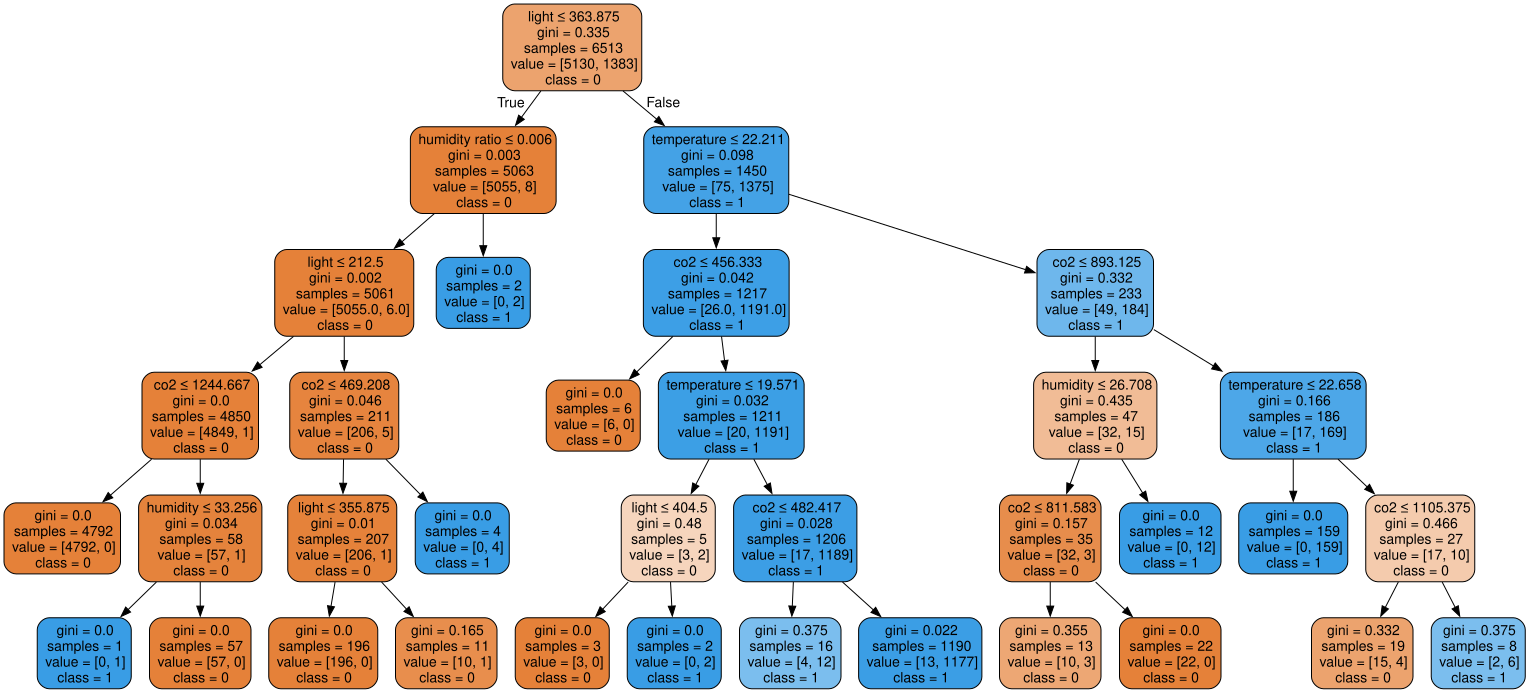

In [17]:
def tree_string(tree, x, y):
	return export_graphviz(
		tree,
		out_file=None,
		feature_names=x.columns,
		class_names=[str(i) for i in sorted(y.unique())],
		filled=True,
		rounded=True,
		special_characters=True
	)

graph_gini = graphviz.Source(tree_string(tree_gini, x, y))
graph_gini

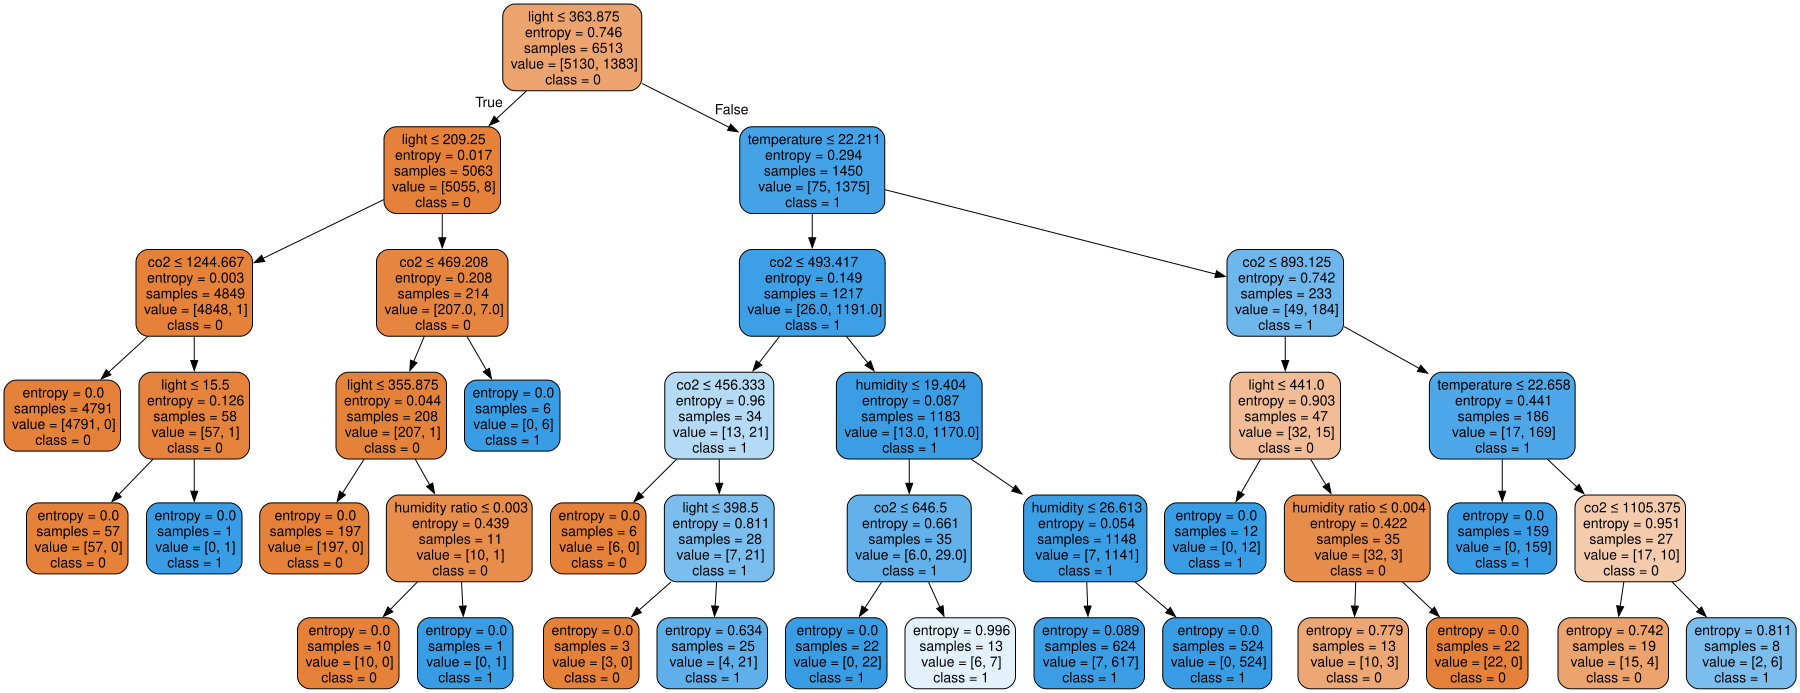

In [18]:
graph_entropy = graphviz.Source(tree_string(tree_entropy, x, y))
graph_entropy

7. Обчислити класифікаційні метрики збудованої моделі для тренувальної
та тестової вибірки. Представити результати роботи моделі на тестовій
вибірці графічно. Порівняти результати, отриманні при застосуванні
різних критеріїв розщеплення: інформаційний приріст на основі
ентропії чи неоднорідності Джині.

Оцінка моделі з критерієм Джині
Коефіцієнт кореляції Мет'ю для тренувальної вибірки: 0.9876554428659159
Коефіцієнт кореляції Мет'ю для тестової вибірки: 0.989040996672155

Звіт класифікації:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1284
           1       0.99      1.00      0.99       345

    accuracy                           1.00      1629
   macro avg       0.99      1.00      0.99      1629
weighted avg       1.00      1.00      1.00      1629


Оцінка моделі з критерієм ентропії
Коефіцієнт кореляції Мет'ю для тренувальної вибірки: 0.988118622800178
Коефіцієнт кореляції Мет'ю для тестової вибірки: 0.9872383451710586

Звіт класифікації:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1284
           1       0.98      1.00      0.99       345

    accuracy                           1.00      1629
   macro avg       0.99      1.00      0.99      1629
weighted avg   

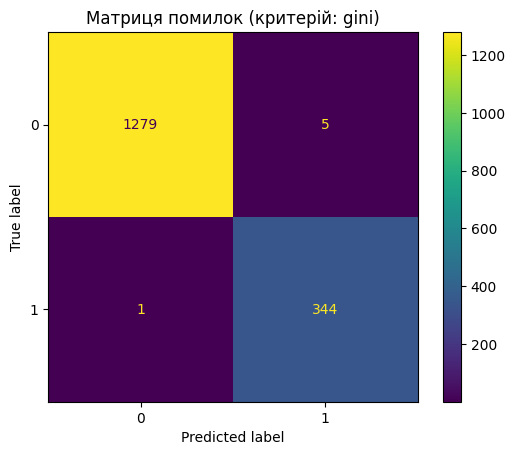

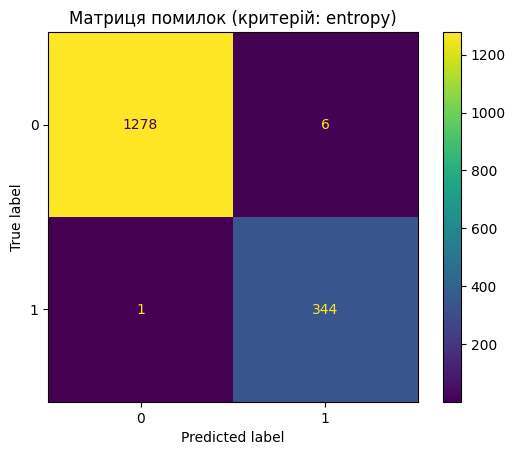

In [19]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, matthews_corrcoef
import matplotlib.pyplot as plt

def evaluate_model(model, x_train, x_test, y_train, y_test):
  y_train_pred= model.predict(x_train)
  matthewscoef_train = matthews_corrcoef(y_train, y_train_pred)
  print(f"Коефіцієнт кореляції Мет'ю для тренувальної вибірки: {matthewscoef_train}")
  
  y_test_pred = model.predict(x_test)
  matthewscoef_test = matthews_corrcoef(y_test, y_test_pred)
  print(f"Коефіцієнт кореляції Мет'ю для тестової вибірки: {matthewscoef_test}")
  
  print("\nЗвіт класифікації:")
  print(classification_report(y_test, y_test_pred, zero_division=0))
  
  ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)
  plt.title(f"Матриця помилок (критерій: {model.criterion})")
  plt.show

print("Оцінка моделі з критерієм Джині")
evaluate_model(tree_gini, x_train, x_test, y_train, y_test)

print("\nОцінка моделі з критерієм ентропії")
evaluate_model(tree_entropy, x_train, x_test, y_train, y_test)
  

В даному випадку різні критерії розщеплення не дуже сильно повпливали на результат, модель з критерієм Джині правильно визначила лише на 1 подію більше. Хоча на такій великій вибірці це практично непомітно, але, скажімо, якби моделі перевіряли зайнятість кімнати, що здається в оренду, то використовуючи модель з критерієм ентропії ми б втратили потенційний прибуток від здачі в оренду шести кімнат, коли для другої моделі ми б втратили прибуток від здачі в оренду п'яти кімнат.

8. З’ясувати вплив максимальної кількості листів та мінімальної кількості
елементів в листі дерева на результати класифікації. Результати
представити графічно.

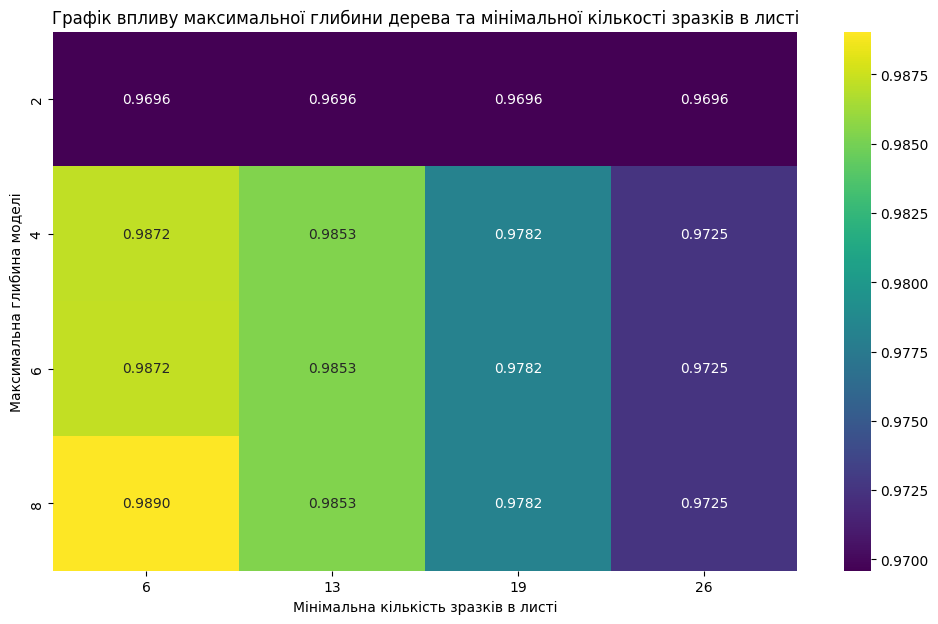

In [27]:
import seaborn as sns

depths = [i for i in range(2, 10, 2)]

## Тут зробив менше, ніж ви вказали на практичному занятті (5-15% від загальної кількості записів), бо якщо поставити від 1%, коефіцієнт кореляції виходить однаковим, дерева виходять однаковими, тому для цікавості і гарного графіку мінімум рахується від 0,1%
min_samples = [int(i*0.001*x_train.shape[0]) for i in range(1, 5)]

coef_results = []

for depth in depths:
	for min_sample in min_samples:

		tree = DecisionTreeClassifier(max_depth=depth, random_state=129, min_samples_leaf=min_sample)
		tree.fit(x_train, y_train)

		y_pred = tree.predict(x_test)
		coef = matthews_corrcoef(y_test, y_pred)
		coef_results.append({
			"depth": depth, 
			"min_samples": min_sample, 
			"mcc": coef
		})
        
res = pd.DataFrame(coef_results)
df_pivot = res.pivot(
    index="depth", 
    columns="min_samples", 
    values="mcc"
)

plt.figure(figsize=(12, 7)) 
sns.heatmap(
	df_pivot, 
	annot=True,     
	fmt=".4f",      
	cmap="viridis" 
)

plt.title("Графік впливу максимальної глибини дерева та мінімальної кількості зразків в листі")
plt.xlabel("Мінімальна кількість зразків в листі")
plt.ylabel("Максимальна глибина моделі")
plt.show()


9. Навести стовпчикову діаграму важливості атрибутів, які
використовувалися для класифікації (див. feature_importances_).
Пояснити, яким чином – на Вашу думку – цю важливість можна
підрахувати.

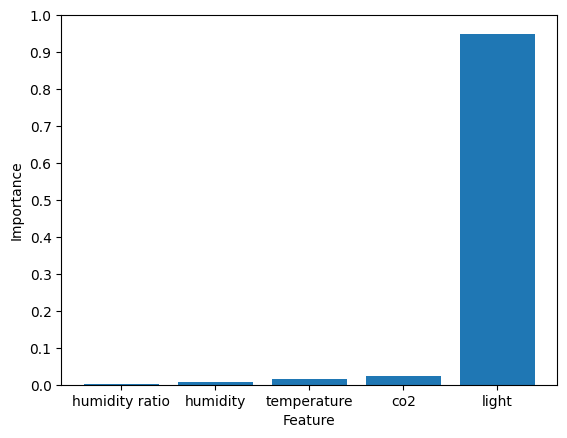

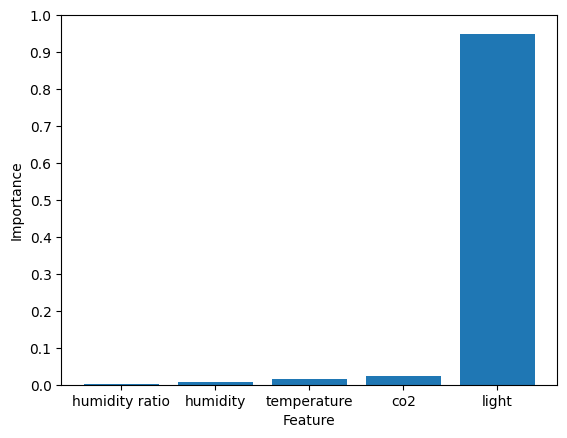

In [21]:
import numpy as np

ticks = np.arange(0, 1.1, 0.1) 

importances_gini = tree_gini.feature_importances_

df_importances_gini = pd.DataFrame({
	"feature": x.columns,
	"importance": importances_gini
}).sort_values(by="importance")

df_importances_gini

plt.bar(df_importances_gini["feature"], df_importances_gini["importance"])
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.yticks(ticks)
plt.show()

importances_entropy = tree_entropy.feature_importances_

df_importances_entropy = pd.DataFrame({
	"feature": x.columns,
	"importance": importances_gini
}).sort_values(by="importance")

df_importances_entropy

plt.bar(df_importances_entropy["feature"], df_importances_entropy["importance"])
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.yticks(ticks)
plt.show()

Можу припустити, що важливість атрибутів рахується, враховуючи наскільки якісно вдалось розбити датасет у вузлі, використовуючи той чи інший артибут. За графіками бачимо, що кількість світла у кімнаті є найбільш важливою. Я можу припустити що так відбувається, бо в першому ж вузлі обидві моделі розбивають датасет на дві підмножини з дуже хорошим результатом: перша є майже чистою за класом 0, маючи тільки 8 записів 1 класу, у друга є майже чистою за класом 1, маючи тільки 75 записів 0 класу. Рівень ентропії та індекса джині знизився з високої неоднорідності до малих значень. Можливо, важливість атрибуту рахується відповідно до різниці критеріїв розщеплення батьківського та дочірнього вузлів, підсумовуючись по усіх вузлах, в яких задіяний цей атрибут. 